# ChemAI: Predict the Cure

Цель проекта — предсказать биологическую активность химических соединений против вируса гриппа по молекулярным дескрипторам.

Предсказываемые переменные:
- IC50 — концентрация подавления 50% активности вируса
- CC50 — токсичность для 50% клеток
- SI — индекс селективности

Метрика соревнования: средний RMSE по трём таргетам.

Основной подход:

1. Базовая очистка данных и проверка качества выборки
2. Отбор информативных признаков и удаление константных признаков
3. Обучение отдельных моделей для таргетов IC50 и CC50
4. Анализ взаимосвязи между таргетами
5. Построение relation-aware модели для SI
6. Постобработка предсказаний и стабилизация SI
7. Формирование финального submission-файла

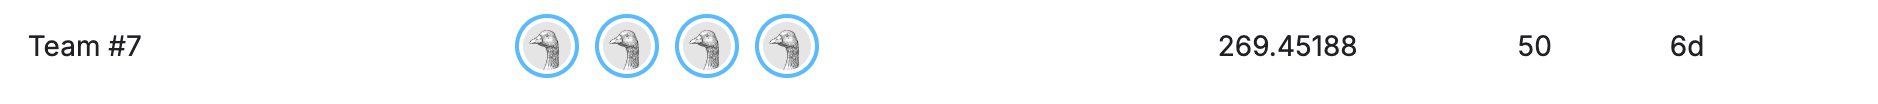

## Подготовка окружения

Импортируем библиотеки, фиксируем seed и создаём конфигурацию проекта.

In [ ]:
!pip install -q catboost

In [43]:
import os
import random
import warnings
warnings.filterwarnings("ignore")


import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

from catboost import CatBoostRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything()


## 1. Загрузка данных

In [44]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print(train.shape)
print(test.shape)

train.head()
test.head()

(751, 214)
(250, 211)


,index,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,13.761882,13.761882,0.121946,-0.962625,0.770057,30.580645,450.541,432.397,450.070799,...,1,0,0,0,0,0,0,1,0,0
1,1,13.224489,13.224489,0.066132,-1.801871,0.278628,25.687500,448.380,428.220,448.100561,...,0,0,0,0,0,0,0,0,0,0
2,2,6.191528,6.191528,0.445278,0.445278,0.657472,55.384615,179.307,158.139,179.167400,...,0,0,0,0,0,0,0,0,0,0
3,3,14.061236,14.061236,0.054870,-6.660336,0.564307,23.464286,410.289,397.185,410.086525,...,0,0,0,0,0,0,0,0,0,0
4,4,12.790378,12.790378,0.320463,-1.642616,0.696213,22.000000,280.279,268.183,280.073559,...,0,0,0,0,0,0,0,0,0,0


После загрузки мы получили обучающую выборку из 751 строки и 214 колонок. Тестовая выборка содержит 250 строк и 211 колонок: на три колонки меньше, так как в ней отсутствуют целевые переменные IC50, CC50 и SI, которые нам предстоит предсказать. Файл sample_submission также состоит из 250 строк и 4 колонок (индекс и три таргета), что полностью соответствует структуре тестовой выборки.

### Нормализация колонок

In [45]:
train.columns = [c.strip().replace(", mM", "").replace(" ", "_") for c in train.columns]
test.columns = [c.strip().replace(", mM", "").replace(" ", "_") for c in test.columns]
sample_submission.columns = [c.strip().replace(", mM", "").replace(" ", "_") for c in sample_submission.columns]

В исходных названиях были пробелы, запятые и единицы измерения (например, "IC50, mM"). Мы удалили все лишние символы, чтобы упростить обращение к колонкам в коде.

## 2. Базовая проверка данных

Проверяем размеры, типы признаков, пропуски, дубликаты, распределение таргетов.

In [46]:
TARGETS = ["IC50", "CC50", "SI"]
ID_COL = "index"

features = [
    c for c in train.columns
    if c not in TARGETS + [ID_COL]
]

print("Кол-во признаков до очистки:", len(features))

Кол-во признаков до очистки: 210


In [47]:
print("\nТипы данных:")
display(train.dtypes.head())

print("\nПропуски:")
display(train.isna().sum().sort_values(ascending=False).head())

print("\nДубликаты:")
print(train.duplicated().sum())


Типы данных:


index                  int64
IC50                 float64
CC50                 float64
SI                   float64
MaxAbsEStateIndex    float64
dtype: object


Пропуски:


MinAbsPartialCharge    2
BCUT2D_LOGPHI          2
BCUT2D_MWHI            2
MaxAbsPartialCharge    2
MinPartialCharge       2
dtype: int64


Дубликаты:
0


### Проверка константных признаков

In [48]:
constant_cols = [
    c for c in features
    if train[c].nunique() <= 1
]

print("Константные колонки:", len(constant_cols))

features = [
    c for c in features
    if c not in constant_cols
]

print("Кол-во признаков после очистки:", len(features))

Константные колонки: 18
Кол-во признаков после очистки: 192


### Вывод по очистке данных

Все признаки имеют числовой тип (float64/int64), поэтому дополнительных преобразований не требуется.

Мы обнаружили 5 признаков с пропусками (MaxAbsPartialCharge, MinAbsPartialCharge, MaxPartialCharge, MinPartialCharge, BCUT2D_MWLOW) — в каждом по 2 пропуска, что составляет менее 0.3% от всех данных. Мы решили не заполнять пропуски, так как CatBoost умеет работать с ними самостоятельно.

Дубликаты строк отсутствуют. Данные хорошего качества и не требуют агрессивной предобработки.

В обучающей выборке были обнаружены признаки с единственным уникальным значением. Такие признаки не содержат полезной информации для модели и были удалены из дальнейшего анализа.

### CV метрика

In [49]:
def competition_rmse(y_true, y_pred):
    scores = {}

    for i, target in enumerate(TARGETS):
        mse = mean_squared_error(
            y_true[:, i],
            y_pred[:, i]
        )

        rmse = np.sqrt(mse)
        scores[target] = rmse

    mean_score = np.mean(list(scores.values()))

    return mean_score, scores

Функция competition_rmse считает RMSE для каждого из трёх таргетов (IC50, CC50, SI) и возвращает их среднее — именно это значение является итоговой метрикой соревнования.

## 3. Подготовка данных

In [50]:
X = train[features].copy()
y = train[TARGETS].copy()
X_test = test[features].copy()

print(X.shape, y.shape, X_test.shape)

(751, 192) (751, 3) (250, 192)


После очистки признаков мы сформировали матрицу обучающих признаков X размером 751×192, матрицу целевых переменных y размером 751×3 и тестовую матрицу X_test размером 250×192. Все признаки числовые, дополнительного масштабирования не требуется, так как CatBoost не чувствителен к масштабу данных.

### Подготовка CV

In [51]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

Мы используем 5-кратную KFold с перемешиванием данных и фиксированным seed=42. Это обеспечивает воспроизводимость и стабильную оценку качества модели.

## 4. Финальная стратегия решения

По результатам экспериментов лучший Kaggle score был получен не за счёт усложнения моделей, а за счёт использования связи между таргетами.

Финальный подход:
1. IC50 обучается отдельной регуляризованной CatBoost-моделью.
2. CC50 обучается отдельной регуляризованной CatBoost-моделью.
3. SI не предсказывается как независимый таргет.
4. SI рассчитывается через relation-aware формулу:

SI ≈ CC50 / IC50

5. Для стабилизации знаменателя используется мягкий clipping IC50 по квантилям 0.003–0.997.
6. Финальный SI считается как:

SI_final = 0.88 * SI_formula + 0.12 * SI_model

### Функция обучения CatBoost

In [52]:
def train_catboost_with_eval(
    X,
    y,
    X_test,
    target_name,
    params,
    kf
):
    oof = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    fold_scores = []

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X), 1):
        print(f"\n========== {target_name} | Fold {fold} ==========")

        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train = y.iloc[train_idx][target_name]
        y_valid = y.iloc[valid_idx][target_name]

        model = CatBoostRegressor(**params)

        model.fit(
            X_train,
            y_train,
            eval_set=(X_valid, y_valid),
            use_best_model=True
        )

        valid_preds = model.predict(X_valid)
        test_fold_preds = model.predict(X_test)

        valid_preds = np.maximum(valid_preds, 0)
        test_fold_preds = np.maximum(test_fold_preds, 0)

        oof[valid_idx] = valid_preds
        test_preds += test_fold_preds / kf.n_splits

        rmse = np.sqrt(mean_squared_error(y_valid, valid_preds))
        fold_scores.append(rmse)

        print(f"{target_name} Fold RMSE:", rmse)

    cv = np.sqrt(mean_squared_error(y[target_name], oof))

    print(f"\n{target_name} CV:", cv)
    print(f"{target_name} STD:", np.std(fold_scores))

    return {
        "oof": oof,
        "test_preds": test_preds,
        "cv": cv,
        "std": np.std(fold_scores),
        "fold_scores": fold_scores
    }

### Функция обучения SI-модели

In [53]:
def train_log_model_target(
    model,
    X,
    y,
    X_test,
    target_name,
    kf
):
    oof = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    fold_scores = []

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X), 1):
        print(f"\n========== {target_name} | Fold {fold} ==========")

        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train = y.iloc[train_idx][target_name]
        y_valid = y.iloc[valid_idx][target_name]

        y_train_log = np.log1p(y_train)

        model.fit(X_train, y_train_log)

        valid_preds = np.expm1(model.predict(X_valid))
        test_fold_preds = np.expm1(model.predict(X_test))

        valid_preds = np.maximum(valid_preds, 0)
        test_fold_preds = np.maximum(test_fold_preds, 0)

        oof[valid_idx] = valid_preds
        test_preds += test_fold_preds / kf.n_splits

        rmse = np.sqrt(mean_squared_error(y_valid, valid_preds))
        fold_scores.append(rmse)

        print(f"{target_name} Fold RMSE:", rmse)

    cv = np.sqrt(mean_squared_error(y[target_name], oof))

    print(f"\n{target_name} CV:", cv)
    print(f"{target_name} STD:", np.std(fold_scores))

    return {
        "oof": oof,
        "test_preds": test_preds,
        "cv": cv,
        "std": np.std(fold_scores),
        "fold_scores": fold_scores
    }

### Параметры моделей

In [54]:
ic50_regularized_params = {
    "loss_function": "RMSE",
    "iterations": 5000,
    "learning_rate": 0.015,
    "depth": 3,
    "l2_leaf_reg": 10,
    "random_seed": SEED,
    "verbose": 300,
    "early_stopping_rounds": 300,
    "allow_writing_files": False
}

cc50_regularized_params = {
    "loss_function": "RMSE",
    "iterations": 5000,
    "learning_rate": 0.015,
    "depth": 3,
    "l2_leaf_reg": 10,
    "random_seed": SEED,
    "verbose": 300,
    "early_stopping_rounds": 300,
    "allow_writing_files": False
}

si_model_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", ExtraTreesRegressor(
        n_estimators=1200,
        max_depth=12,
        min_samples_leaf=2,
        max_features=0.7,
        random_state=SEED,
        n_jobs=-1
    ))
])

### Обучение моделей  

Обучаем IC50 и CC50 отдельными CatBoost-моделями.  
SI-модель обучается отдельно и используется только как небольшая поправка к формульному SI.

## Архитектура финального решения

Общая схема пайплайна:  

Признаки  
↓  
CatBoost → IC50  
↓  
CatBoost → CC50  
↓  
ExtraTrees → SI_model  
↓  
SI_formula = CC50 / IC50  
↓  
SI_final = 0.88 × SI_formula + 0.12 × SI_model  
↓  
Submission

In [55]:
regularized_ic50 = train_catboost_with_eval(
    X=X,
    y=y,
    X_test=X_test,
    target_name="IC50",
    params=ic50_regularized_params,
    kf=kf
)

regularized_cc50 = train_catboost_with_eval(
    X=X,
    y=y,
    X_test=X_test,
    target_name="CC50",
    params=cc50_regularized_params,
    kf=kf
)

si_model_result = train_log_model_target(
    model=si_model_pipeline,
    X=X,
    y=y,
    X_test=X_test,
    target_name="SI",
    kf=kf
)


========== IC50 | Fold 1 ==========
0:	learn: 352.9294243	test: 429.5702936	best: 429.5702936 (0)	total: 1.54ms	remaining: 7.68s
300:	learn: 276.3644742	test: 395.9832044	best: 395.9832044 (300)	total: 288ms	remaining: 4.49s
600:	learn: 255.0500346	test: 394.0073591	best: 393.9814452 (599)	total: 648ms	remaining: 4.74s
900:	learn: 239.1731585	test: 393.6396653	best: 393.3716762 (894)	total: 994ms	remaining: 4.52s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 393.3716762
bestIteration = 894

Shrink model to first 895 iterations.
IC50 Fold RMSE: 393.37168288651037

========== IC50 | Fold 2 ==========
0:	learn: 389.5542820	test: 277.4513809	best: 277.4513809 (0)	total: 1.91ms	remaining: 9.54s
300:	learn: 311.6742383	test: 259.0616180	best: 259.0616180 (300)	total: 234ms	remaining: 3.65s
600:	learn: 278.9096205	test: 258.4680062	best: 258.3405757 (435)	total: 460ms	remaining: 3.37s
900:	learn: 255.3801963	test: 256.1076667	best: 255.8404554 (886)	total: 681ms	remainin

### Проверка связи между таргетами

Проверяем гипотезу, что SI связан с IC50 и CC50 через отношение CC50 / IC50.

In [56]:
formula_si_train = train["CC50"] / (train["IC50"] + 1e-6)

formula_rmse = np.sqrt(mean_squared_error(train["SI"], formula_si_train))
formula_corr = np.corrcoef(train["SI"], formula_si_train)[0, 1]

print("Formula SI RMSE:", formula_rmse)
print("Formula SI correlation:", formula_corr)

display(pd.DataFrame({
    "SI_true": train["SI"],
    "SI_formula": formula_si_train,
    "diff": train["SI"] - formula_si_train
}).describe())

Formula SI RMSE: 0.07208447488173943
Formula SI correlation: 0.9999999981198611


,SI_true,SI_formula,diff
count,751.000000,751.000000,7.510000e+02
mean,89.153313,89.148705,4.608816e-03
std,788.882198,788.828890,7.198493e-02
min,0.011489,0.011489,1.883587e-10
25%,1.500000,1.500000,1.000010e-08
50%,4.000000,4.000000,1.000986e-07
75%,17.372463,17.372463,9.925415e-07
max,15620.600000,15619.624045,1.616684e+00


### Вывод о связи между таргетами

Полученная корреляция подтверждает наличие сильной связи между SI и отношением CC50 / IC50.

Это означает, что SI не является полностью независимым таргетом.

Данное наблюдение позволило перейти от прямого прогнозирования SI к relation-aware подходу, основанному на использовании предсказанных значений IC50 и CC50.

### Финальная OOF-оценка

Формируем финальные OOF-предсказания:
- IC50: регуляризованный CatBoost
- CC50: регуляризованный CatBoost
- SI: relation-aware формула + небольшая модельная поправка

## Стабилизация предсказаний IC50

В ходе экспериментов было обнаружено,
что небольшое количество экстремальных предсказаний IC50
существенно ухудшает итоговую метрику.

Поскольку IC50 используется в знаменателе при расчёте SI,
даже небольшие ошибки могут приводить к сильному искажению итогового значения.

Для уменьшения влияния выбросов используется мягкое ограничение предсказаний IC50 по квантилям 0.003–0.997.

In [57]:
ic50_clip_low = train["IC50"].quantile(0.003)
ic50_clip_high = train["IC50"].quantile(0.997)

print("IC50 clip low:", ic50_clip_low)
print("IC50 clip high:", ic50_clip_high)

IC50 clip low: 0.016291175430995477
IC50 clip high: 2083.3667892781914


In [58]:
oof_ic50_clipped = np.clip(
    regularized_ic50["oof"],
    ic50_clip_low,
    ic50_clip_high
)

oof_cc50 = regularized_cc50["oof"]
oof_si_model = si_model_result["oof"]

oof_si_formula = oof_cc50 / (oof_ic50_clipped + 1e-6)

oof_si_formula = np.clip(
    oof_si_formula,
    0,
    train["SI"].quantile(0.995)
)

oof_si_final = 0.88 * oof_si_formula + 0.12 * oof_si_model

final_oof = np.column_stack([
    oof_ic50_clipped,
    oof_cc50,
    oof_si_final
])

final_cv, final_details = competition_rmse(
    y.values,
    final_oof
)

print("Final CV RMSE:", final_cv)
print(final_details)

Final CV RMSE: 522.9493303435621
{'IC50': np.float64(322.0611274676998), 'CC50': np.float64(444.7628417179687), 'SI': np.float64(802.024021845018)}


## Формирование итогового решения

После обучения моделей формируются финальные предсказания.

Для IC50 используется регуляризованная CatBoost-модель.

Для CC50 используется регуляризованная CatBoost-модель.

Для SI используется комбинация:
- расчётного значения по формуле CC50 / IC50;
- отдельной модели ExtraTrees.

Такой подход позволяет использовать как предметную зависимость между таргетами,
так и информацию, извлекаемую моделью напрямую из признаков.

### Создание финального submission

Финальный файл соответствует лучшей Kaggle-стратегии:
IC50 clipping 0.003–0.997 + relation-aware SI.

In [59]:
test_ic50_clipped = np.clip(
    regularized_ic50["test_preds"],
    ic50_clip_low,
    ic50_clip_high
)

test_cc50 = regularized_cc50["test_preds"]
test_si_model = si_model_result["test_preds"]

test_si_formula = test_cc50 / (test_ic50_clipped + 1e-6)

test_si_formula = np.clip(
    test_si_formula,
    0,
    train["SI"].quantile(0.995)
)

test_si_final = 0.88 * test_si_formula + 0.12 * test_si_model

submission = sample_submission.copy()

submission["IC50"] = test_ic50_clipped
submission["CC50"] = test_cc50
submission["SI"] = test_si_final

submission_name = "submission_strategy9_ic50_clip_0003_0997.csv"

submission.to_csv(submission_name, index=False)

submission.head()

,index,IC50,CC50,SI
0,0,155.013075,296.260094,2.285055
1,1,199.052315,385.679189,2.228112
2,2,55.560908,301.953105,5.555393
3,3,261.101007,408.811716,1.894883
4,4,187.044834,335.940632,1.867745


## Финальные выводы

Лучший Kaggle score: 269.45188.

Финальный подход:
1. IC50 и CC50 обучаются отдельными CatBoost-моделями.
2. SI не предсказывается как полностью независимый таргет.
3. Используется предметная зависимость:

   SI ≈ CC50 / IC50

4. Для стабилизации отношения применяется мягкий clipping IC50 по квантилям 0.003–0.997.
5. Финальный SI рассчитывается как blend:

   SI_final = 0.88 * SI_formula + 0.12 * SI_model

Главный вывод:
наибольший прирост качества был получен не за счёт усложнения моделей, а за счёт анализа связи между таргетами и стабилизации формульного SI.

### Воспроизводимость результатов

- Используется фиксированный seed: 42
- Кросс-валидация: 5-fold KFold с перемешиванием данных (`shuffle=True`)
- Внешние данные не использовались
- Таргеты тестовой выборки не использовались при обучении
- Финальный submission-файл полностью генерируется данным ноутбуком  

Полученный результат показывает,
что для данной задачи наибольший вклад в качество модели внесло понимание структуры таргетов,
а не усложнение алгоритмов машинного обучения.

Наиболее эффективным оказался подход,
использующий предметную зависимость между IC50, CC50 и SI,
что позволило значительно улучшить качество предсказаний по сравнению с базовыми моделями.

## Возможные улучшения

1. Feature engineering: создание дополнительных дескрипторов (отношения, разности, произведения)
2. Ансамблирование: блендинг нескольких моделей (XGBoost, LightGBM, CatBoost)
3. Оптимизация порогов clipping: подбор квантилей для IC50
4. Оптимизация веса blend: подбор коэффициента для SI_formula и SI_model
5. Постобработка: сглаживание предсказаний, исправление аномалий